In [31]:
# ==========================================
# CUSTOMER SEGMENTATION USING K-MEANS
# AND HIERARCHICAL CLUSTERING
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering


In [32]:
# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv("/content/sample_data/Mall_Customers.csv")

print(df.head())
print(df.info())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [33]:

# ==========================================
# DATA EXPLORATION
# ==========================================

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistics")
print(df.describe())


Missing Values
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Statistics
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


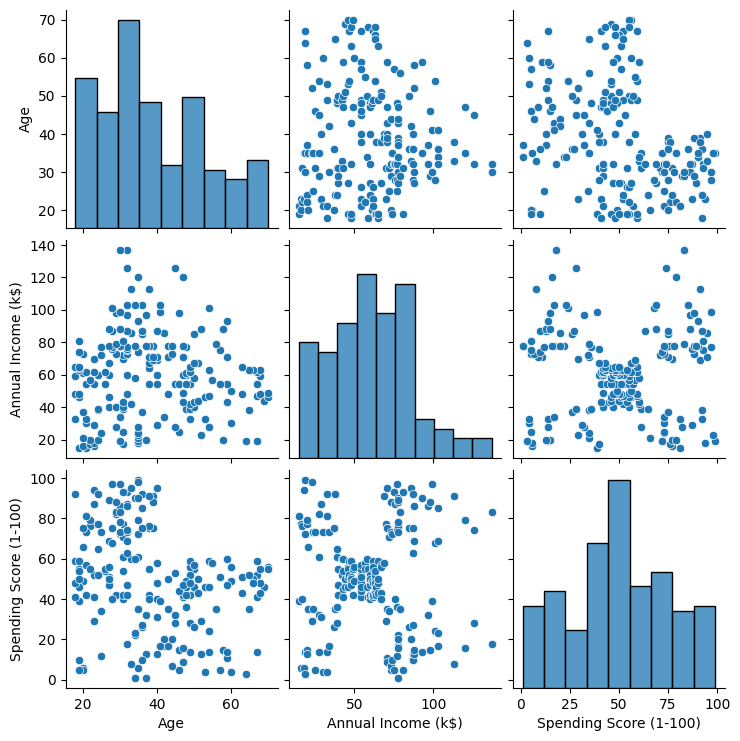

In [34]:
# ==========================================
# VISUALIZATION
# ==========================================

sns.pairplot(df[['Age',
                 'Annual Income (k$)',
                 'Spending Score (1-100)']])

plt.show()

In [35]:

# ==========================================
# FEATURE SELECTION
# ==========================================

X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

In [36]:
# ==========================================
# FEATURE SCALING
# ==========================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

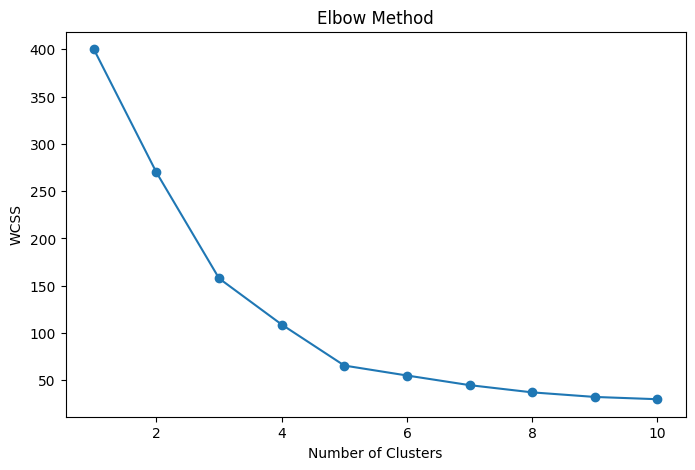

In [37]:
# ==========================================
# ELBOW METHOD
# ==========================================

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [38]:

# ==========================================
# K-MEANS MODEL
# ==========================================

kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = clusters

print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   KMeans_Cluster  
0               3  
1               4  
2               3  
3               4  
4               3  


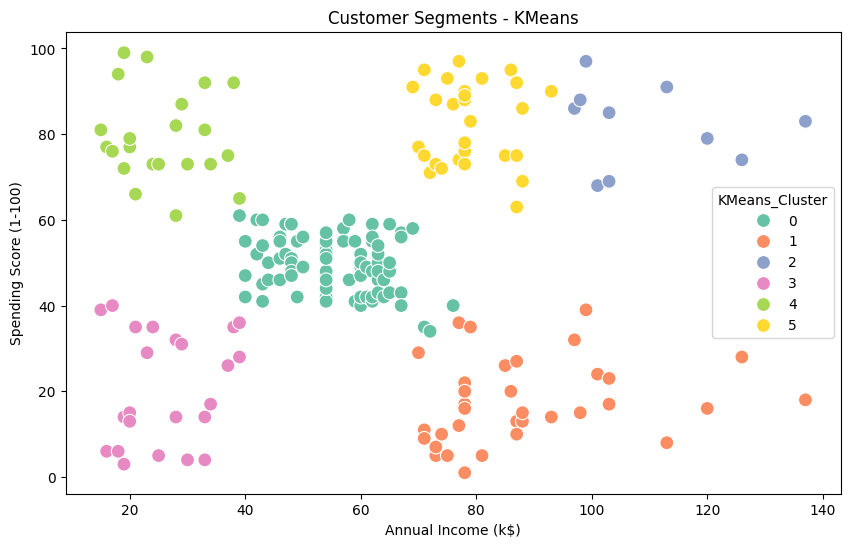

In [39]:
# ==========================================
# VISUALIZE K-MEANS CLUSTERS
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='KMeans_Cluster',
    palette='Set2',
    s=100
)

plt.title("Customer Segments - KMeans")
plt.show()


In [40]:
# ==========================================
# CLUSTER SUMMARY
# ==========================================

summary = df.groupby('KMeans_Cluster').agg({
    'Age':'mean',
    'Annual Income (k$)':'mean',
    'Spending Score (1-100)':'mean'
})

print("\nCluster Summary")
print(summary)


Cluster Summary
                      Age  Annual Income (k$)  Spending Score (1-100)
KMeans_Cluster                                                       
0               42.716049           55.296296               49.518519
1               41.114286           88.200000               17.114286
2               32.200000          109.700000               82.000000
3               45.217391           26.304348               20.913043
4               25.272727           25.727273               79.363636
5               32.862069           78.551724               82.172414


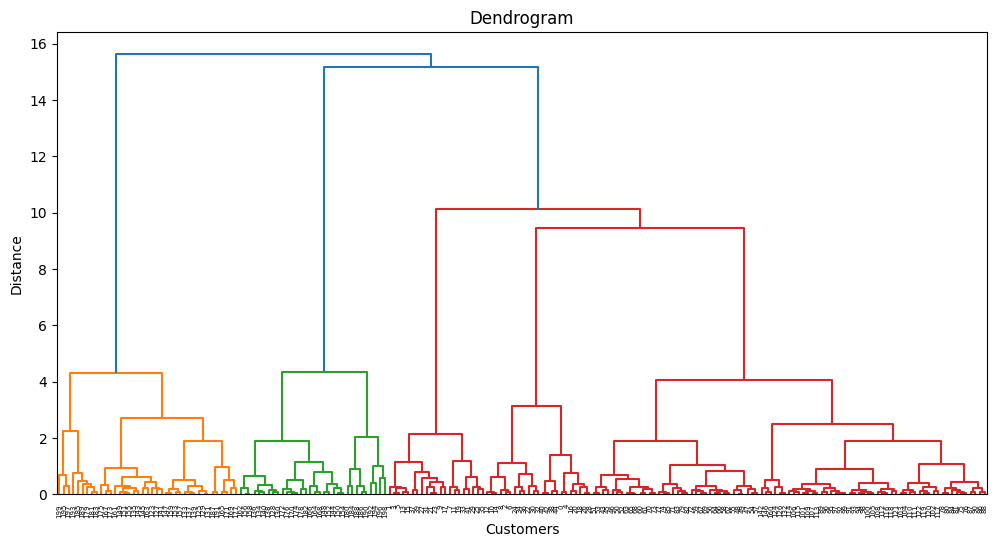

In [41]:
# ==========================================
# HIERARCHICAL CLUSTERING
# ==========================================

plt.figure(figsize=(12,6))

dendrogram(
    linkage(X_scaled,
            method='ward')
)

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [42]:
# ==========================================
# AGGLOMERATIVE CLUSTERING
# ==========================================

hc = AgglomerativeClustering(
    n_clusters=6,
    linkage='ward'
)

hc_labels = hc.fit_predict(X_scaled)

df['Hierarchical_Cluster'] = hc_labels

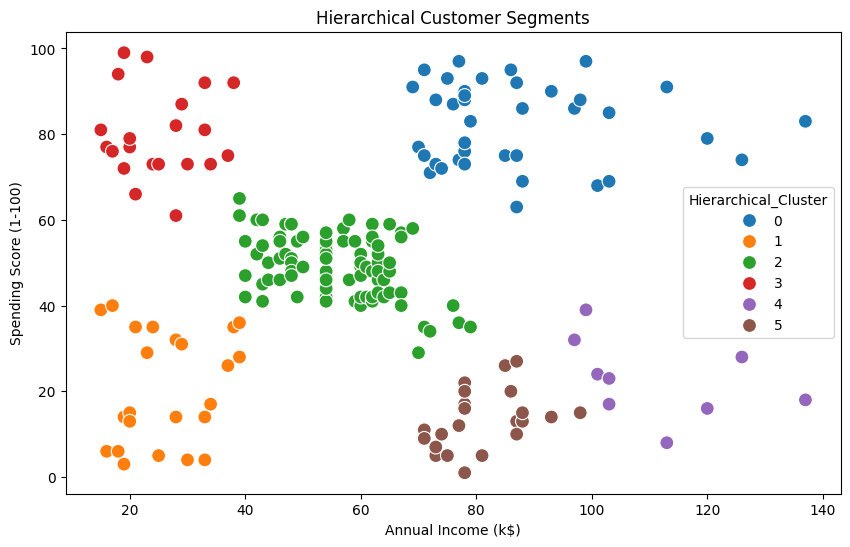

In [43]:
# ==========================================
# VISUALIZE HIERARCHICAL CLUSTERS
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Hierarchical_Cluster',
    palette='tab10',
    s=100
)

plt.title("Hierarchical Customer Segments")
plt.show()

In [44]:
# ==========================================
# SAVE RESULTS
# ==========================================

df.to_csv(
    "customer_segments_output.csv",
    index=False
)

print("\nSegmentation completed successfully.")
print("Output saved as customer_segments_output.csv")


Segmentation completed successfully.
Output saved as customer_segments_output.csv
